# 04 — An experimental-design toolkit

### From a reachability verdict to a screen you can run

Notebooks 01–03 established a convex-cone **reachability oracle** and showed it transfers across cell types, modalities, and combinatorial designs. This notebook turns the oracle into a **design tool**: point it at a *current → target* cell-state transition and get back a calibrated verdict, a ranked minimal perturbation recipe split by required direction, a per-move delivery-technology call grounded in Open Targets, and an optimal next-screen library — exported as a per-target **design card**.

> **The honest-calibration principle.** The in-sample reachable cosine is optimistic. This notebook quantifies *by how much* (held-out-gene reliability, gene-panel bootstrap CIs, nulls) so a researcher knows which verdicts to trust. Heavy results are precomputed; the notebook runs in seconds.

In [1]:
# 04 — An experimental-design toolkit: from a reachability verdict to a screen you can run.
#
# Notebooks 01-03 established the method (a convex-cone reachability oracle) and showed it
# transfers across cell types, modalities, and combinatorial designs. This notebook turns the
# oracle into a DESIGN TOOL: point it at a current -> target cell state and it returns
#   (1) a calibrated reachability verdict,
#   (2) a ranked, minimal perturbation recipe split by required DIRECTION (knockdown vs activation),
#   (3) a per-move DELIVERY-TECHNOLOGY call grounded in Open Targets tractability, and
#   (4) an optimal next-screen LIBRARY (the knee of the sparsity-vs-reach curve),
# exported as a per-target "design card".
#
# The single most important design decision here is HONESTY about calibration: the in-sample
# reachable cosine is optimistic, and this notebook quantifies by how much (held-out-gene
# reliability diagram, gene-panel bootstrap CIs, and nulls) so a researcher knows which verdicts
# to trust. Heavy results are precomputed (cached) — this notebook is CPU-cheap and reproducible.
import os, sys, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib as mpl

sys.path.insert(0, "..")                          # repo root -> reachability.py (v4, has design_experiment)
import reachability as R

CACHE = "cache"; FIG = "figures"; RESULTS = "../results"
os.makedirs(FIG, exist_ok=True)

# self-contained publication styling (mirrors notebooks 02-03 — no external skill dependency)
plt.rcParams.update({"figure.dpi":110,"font.size":8,"axes.titlesize":9,"axes.labelsize":8,
                     "xtick.labelsize":7,"ytick.labelsize":7,"axes.spines.top":False,
                     "axes.spines.right":False,"axes.grid":True,"grid.alpha":0.25})
# color semantics reused across every figure and card
C_LOF, C_GOF, C_NEI = "#1f5fa6", "#c98a2b", "#8a8f98"   # knockdown / activation-only / neither
CONF_C = {"high":"#4c956c", "medium":"#c98a2b", "low":"#c1666b"}

print("reachability module:", [f for f in dir(R) if f in ("design_experiment","signed_reachability","reachability_spectrum")])
print("design_experiment present:", hasattr(R, "design_experiment"))

reachability module: ['design_experiment', 'reachability_spectrum', 'signed_reachability']
design_experiment present: True


## 1 · The design inputs

One genome-wide CD4⁺ T-cell **CRISPRi** screen, three culture conditions. Each `E_<cond>` is a knockdown *effect dictionary* (row = the expression signature of knocking one gene down); each `t_<target>` is the desired *state shift*. A design query is the pair **(dictionary, target shift)**.

In [2]:
# The design inputs. One npz built once from the CD4+ T-cell CRISPRi screen (Schmidt/Marson-style
# genome-wide knockdown, 3 culture conditions). Each E_<cond> is a knockdown effect DICTIONARY:
# row p = the differential-expression signature of knocking down gene p, on the shared 10,282-gene
# readout axis. Each t_<target> is the desired STATE SHIFT (current -> target), same axis.
z = np.load("../analysis_cache/atlas_work/inputs.npz", allow_pickle=True)   # the design inputs (built once; see notebook 01)
var_gene = z["var_gene"]                                             # (10282,) readout gene names
CONDS = ["Rest", "Stim8hr", "Stim48hr"]
E    = {c: z[f"E_{c}"].astype(np.float64) for c in CONDS}           # (P_c, 10282) knockdown dictionaries
GENE = {c: z[f"gene_{c}"] for c in CONDS}                           # (P_c,) perturbed-gene name per row
TARGETS = {n: z[f"t_{n}"] for n in ["toward_Th1","toward_Th2","toward_younger","toward_older"]}
print(f"readout axis: {var_gene.shape[0]} genes")
for c in CONDS:
    print(f"  {c:8s}: {E[c].shape[0]:5d} single-gene knockdown signatures")
print(f"target state-shift vectors: {list(TARGETS)}")
print(f"\nA design query = (a knockdown dictionary E[cond], a target shift d). The oracle asks:")
print(f"  can a NON-NEGATIVE combination of available knockdowns reproduce the target direction,")
print(f"  and if so, which ones and how many?")

readout axis: 10282 genes
  Rest    :  6871 single-gene knockdown signatures
  Stim8hr :  7155 single-gene knockdown signatures
  Stim48hr:  7195 single-gene knockdown signatures
target state-shift vectors: ['toward_Th1', 'toward_Th2', 'toward_younger', 'toward_older']

A design query = (a knockdown dictionary E[cond], a target shift d). The oracle asks:
  can a NON-NEGATIVE combination of available knockdowns reproduce the target direction,
  and if so, which ones and how many?


## 2 · Orientation gate

A screen whose sign you cannot trust is useless for design. Inherited from notebooks 01–03: a CRISPRi knockdown must **lower its own transcript**.

In [3]:
# Orientation gate (inherited from notebooks 01-03; a screen you cannot trust the sign of is
# useless for design). A CRISPRi knockdown must LOWER its own transcript: own-gene effect < 0.
own = []
for c in CONDS:
    gpos = {g:i for i,g in enumerate(var_gene)}
    for p, gname in enumerate(GENE[c]):
        if gname in gpos:
            own.append(E[c][p, gpos[gname]])
own = np.array(own)
print("=== ORIENTATION GATE (CRISPRi: knockdown should LOWER its own gene) ===")
print(f"  own-gene effect over {own.size} perturbations with their target in the readout axis:")
print(f"     median = {np.median(own):+.3f}   ({100*np.mean(own<0):.0f}% negative)")
print(f"  -> sign convention verified; the dictionary is oriented for design.")

=== ORIENTATION GATE (CRISPRi: knockdown should LOWER its own gene) ===
  own-gene effect over 21174 perturbations with their target in the readout axis:
     median = -10.430   (100% negative)
  -> sign convention verified; the dictionary is oriented for design.


## 3 · The API in one call

`design_experiment(E, d)` composes the whole workflow. Here it runs **live on a small synthetic problem** (fast, transparent); the real T-cell cards — which take 1–4 min each because of the held-out significance loop — are loaded precomputed next.

In [4]:
# THE API in one call. design_experiment() composes the whole workflow: signed decomposition
# (split the target into knockdown-reachable / activation-only / neither), a held-out-gene
# significance gate, ranked recipes for each direction, an optimal-k library from the greedy
# sparsity path, and an activation certificate. Here we run it LIVE on a small synthetic problem
# so the call is transparent and fast; the real T-cell cards (which take ~1-4 min each because of
# the held-out loop) are loaded pre-computed in the next cell.
rng = np.random.default_rng(0)
G, P, K = 200, 60, 4
B = rng.standard_normal((K, G))                       # K latent programs
W = np.abs(rng.standard_normal((P, K)))               # each perturbation = non-neg mix of programs
E_demo = W @ B + 0.02*rng.standard_normal((P, G))     # synthetic knockdown dictionary
d_demo = np.abs(rng.standard_normal(K)) @ B           # an in-cone target (reachable by construction)
demo = R.design_experiment(E_demo, d_demo, perturbation_names=[f"g{i}" for i in range(P)],
                           readout_names=[f"r{j}" for j in range(G)], hvg_mask=(d_demo!=0),
                           k_max=10, top=8, n_shuffles=50, seed=0)
print(demo.summary())
print(f"  verdict={demo.verdict!r}  reach_cos={demo.reachable_cosine:.3f}  optimal_k={demo.optimal_k}")
print(f"  null-calibrated={demo.null_calibrated}  (held-out z={demo.held_out_z:.1f})")
print(f"  in-cone synthetic target is recovered with a compact library -> the API works end to end.")

[REACHABLE] reach_cos=1.000 (held-out 1.000, z=10.5)  LOF=1.00/GOF=0.00/neither=0.00  optimal_k=3
  verdict='reachable'  reach_cos=1.000  optimal_k=3
  null-calibrated=True  (held-out z=10.5)
  in-cone synthetic target is recovered with a compact library -> the API works end to end.


## 4 · The twelve design cards

Every card is `design_experiment()` on one of **4 target states × 3 culture conditions**, enriched with modality (Open Targets) and calibration (bootstrap/nulls). See **Figure 1** for the at-a-glance summary.

In [5]:
# The 12 real design cards, precomputed. Every card = design_experiment() run on one of the
# 4 target states x 3 culture conditions, enriched with modality (Open Targets) and calibration
# (bootstrap/nulls) from the two analysis tracks. Loaded from cache/design_cards.json.
cards = json.load(open("cache/design_cards.json"))
cards = {k:v for k,v in cards.items() if not k.startswith("_")}
COND_ORD = {"Rest":0,"Stim8hr":1,"Stim48hr":2}; TGT_ORD = {"toward_Th1":0,"toward_Th2":1,"toward_younger":2,"toward_older":3}
order = sorted(cards, key=lambda tk: (TGT_ORD[cards[tk]["target"]], COND_ORD[cards[tk]["condition"]]))
cards_df = pd.read_csv(f"{RESULTS}/design_cards.csv")
print(f"design cards: {len(cards)} transitions ({len(TGT_ORD)} target states x {len(COND_ORD)} culture conditions)\n")
print(cards_df[["transition","verdict","confidence","reachable_cosine","realized_cosine","gap","optimal_k"]].to_string(index=False))

design cards: 12 transitions (4 target states x 3 culture conditions)

             transition             verdict confidence  reachable_cosine  realized_cosine    gap  optimal_k
        toward_Th1_Rest partially reachable       high            0.6266           0.4464 0.1802          5
     toward_Th1_Stim8hr    weakly reachable     medium            0.5235           0.2927 0.2308          6
    toward_Th1_Stim48hr    weakly reachable     medium            0.5329           0.2994 0.2335          4
        toward_Th2_Rest partially reachable       high            0.6428           0.4584 0.1845          4
     toward_Th2_Stim8hr    weakly reachable     medium            0.5370           0.3038 0.2332          5
    toward_Th2_Stim48hr    weakly reachable     medium            0.5300           0.2586 0.2714          4
    toward_younger_Rest partially reachable        low            0.6262           0.4008 0.2253          4
 toward_younger_Stim8hr    weakly reachable        low           

## 5 · A design card, rendered

`render_design_card()` puts everything a screen designer needs on one screen: verdict + confidence, the **honest (held-out)** reach beside the **optimistic (in-sample)** one, the modality split, ranked recipes with delivery calls, and the optimal library.

In [6]:
# render_design_card(): the researcher-facing "card". Everything a screen designer needs on one
# screen — verdict + confidence, the honest (held-out) reach next to the optimistic (in-sample)
# one, the modality split, the ranked recipes with delivery calls, and the optimal library.
def render_design_card(card: dict, top_moves: int = 6) -> str:
    c = card; cal = c.get("calibration", {}); mod = c.get("modality", {})
    L = ["="*72, f"  DESIGN CARD  -  {c['target']}  ({c['condition']})", "="*72]
    L.append(f"  VERDICT:  {c['verdict'].upper()}      confidence: {cal.get('confidence_label','?').upper()}")
    L.append(f"  reach cosine (in-sample, full panel):  {c['reachable_cosine']:.3f}")
    if cal.get("boot_reach_cos_lo") is not None:
        L.append(f"     gene-panel bootstrap (85%, N=12):  mean {cal['boot_reach_cos_mean']:.3f}, "
                 f"95% CI [{cal['boot_reach_cos_lo']:.3f}, {cal['boot_reach_cos_hi']:.3f}] (robustness, not the point estimate)")
    if cal:
        L.append(f"  reach cosine (held-out, honest):  {cal['realized_cosine']:.3f}   [in-sample overstates by {cal['gap']:.3f}]")
        L.append(f"  significance:  held-out z = {cal['heldout_z']:.1f}")
    L += ["", "  MODALITY SPLIT (of the target norm):",
          f"     knockdown-reachable (LOF):   {c['lof_fraction']*100:4.1f}%",
          f"     activation-only    (GOF):   {c['gof_fraction']*100:4.1f}%   <- CRISPRa/ORF hypothesis",
          f"     neither direction        :   {c['neither_fraction']*100:4.1f}%"]
    if mod.get("headline_modality_message"): L.append(f"     -> {mod['headline_modality_message']}")
    mv = c.get("moves", []); kd = [m for m in mv if m["direction"]=="knockdown"][:top_moves]; ac = [m for m in mv if m["direction"]=="activation"][:top_moves]
    L += ["", f"  KNOCKDOWN RECIPE (suppress; screen the top {c['optimal_k']} as the library):"]
    for m in kd:
        drug = f" [{int(m['n_drugs'])} drugs]" if m.get("n_drugs") else ""
        L.append(f"     {m['recipe_rank']:2d}. {m['gene']:12s} w={m['weight']:.3f}  {m['delivery_call']}{drug}")
    L.append(f"  ACTIVATION RECIPE (induce; CRISPRa hypothesis - not testable in a knockdown screen):")
    for m in ac:
        L.append(f"     {m['recipe_rank']:2d}. {m['gene']:12s} w={m['weight']:.3f}  {m['delivery_call']}")
    lib = c["library"]; kk = c["optimal_k"]
    L += ["", f"  OPTIMAL NEXT-SCREEN LIBRARY (knee at k={kk}):  " + " > ".join(l["gene"] for l in lib[:kk]), "="*72]
    return "\n".join(L)

# the headline: Th2/naive -> Th1 in the Rest condition, the best-calibrated transition
print(render_design_card(cards["toward_Th1_Rest"]))

  DESIGN CARD  -  toward_Th1  (Rest)
  VERDICT:  PARTIALLY REACHABLE      confidence: HIGH
  reach cosine (in-sample, full panel):  0.627
     gene-panel bootstrap (85%, N=12):  mean 0.639, 95% CI [0.633, 0.649] (robustness, not the point estimate)
  reach cosine (held-out, honest):  0.446   [in-sample overstates by 0.180]
  significance:  held-out z = 45.0

  MODALITY SPLIT (of the target norm):
     knockdown-reachable (LOF):   39.3%
     activation-only    (GOF):   25.3%   <- CRISPRa/ORF hypothesis
     neither direction        :   35.4%
     -> 39% of the addressable shift needs INDUCTION (CRISPRa/ORF); a knockdown-only screen structurally cannot reach it. 1/15 knockdown targets have an approved/clinical drug for repurposing.

  KNOCKDOWN RECIPE (suppress; screen the top 5 as the library):
      1. ICOS         w=0.254  CRISPRi or antibody blockade (surface; 4 drugs) [4 drugs]
      2. C2CD5        w=0.187  CRISPRi or antibody blockade (surface protein)
      3. ADCK2        w=0.17

## 6 · Why the honest number matters — calibration

The in-sample cosine is what an un-cross-validated fit reports; the held-out-gene cosine is what *generalises*. Across all 12 transitions the former overstates the latter by **~0.22**. **Figure 3** (reliability diagram): every point sits below the identity line.

=== calibration: in-sample vs held-out reach (all 12 transitions) ===
  mean in-sample (predicted):  0.580
  mean held-out  (realized) :  0.355
  mean overstatement (gap)  :  0.225   (range 0.18-0.27)
  transitions where in-sample > held-out: 12/12  (systematic, not noise)

  Confidence labels (rule: HIGH = held-out z>20 & gap<0.20 & donor-repro>=0.10; else MEDIUM/LOW):
    {'high': 2, 'medium': 6, 'low': 4}

Figure 3 (reliability diagram) — every point sits below the identity line:
  figures/nb04_fig3_reliability.png


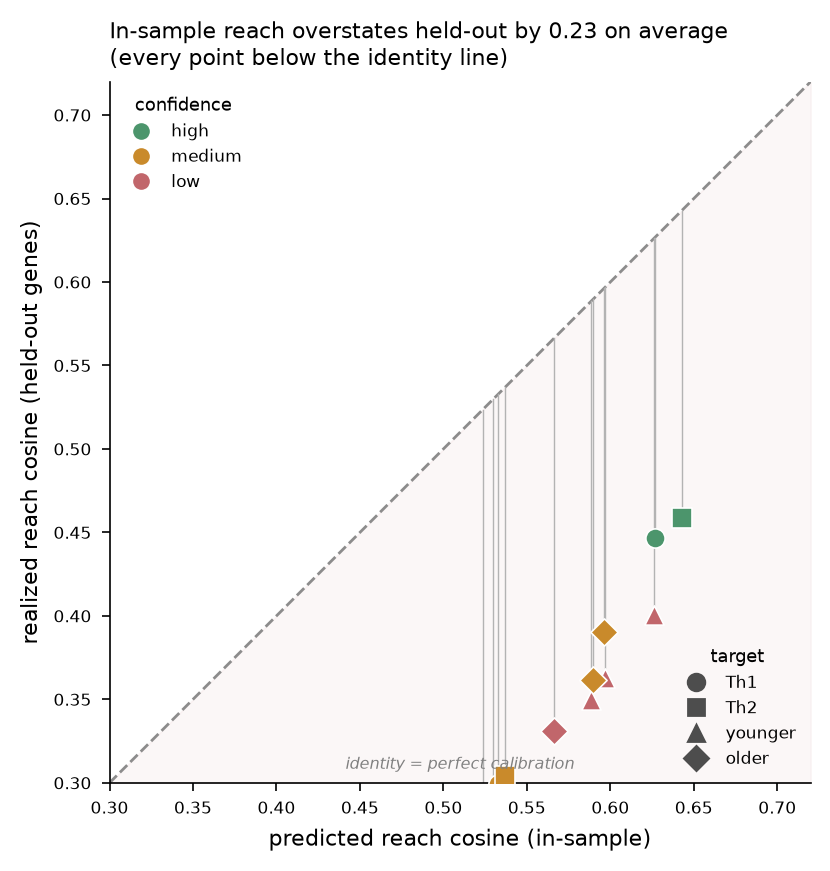

In [7]:
# WHY the honest number matters — the calibration story (Figure 3). The in-sample reachable cosine
# is what an un-cross-validated fit reports; the held-out-gene cosine is what actually generalises.
# Across all 12 transitions the former OVERSTATES the latter by a mean of ~0.22. This is the gap
# between "the cone can be aligned to the target" and "the aligned direction predicts unseen genes".
cal = pd.read_csv(f"{RESULTS}/design_calibration.csv")
gap = (cal["predicted_cosine"] - cal["realized_cosine"])
print("=== calibration: in-sample vs held-out reach (all 12 transitions) ===")
print(f"  mean in-sample (predicted):  {cal['predicted_cosine'].mean():.3f}")
print(f"  mean held-out  (realized) :  {cal['realized_cosine'].mean():.3f}")
print(f"  mean overstatement (gap)  :  {gap.mean():.3f}   (range {gap.min():.2f}-{gap.max():.2f})")
print(f"  transitions where in-sample > held-out: {int((gap>0).sum())}/{len(cal)}  (systematic, not noise)")
print(f"\n  Confidence labels (rule: HIGH = held-out z>20 & gap<0.20 & donor-repro>=0.10; else MEDIUM/LOW):")
print("   ", cal["confidence_label"].value_counts().reindex(["high","medium","low"]).to_dict())
print(f"\nFigure 3 (reliability diagram) — every point sits below the identity line:")
print(f"  {FIG}/nb04_fig3_reliability.png")

## 7 · Modality triage — the scientific payload

The signed decomposition splits each target into a **knockdown-reachable** part (what a CRISPRi screen can do) and an **activation-only** part that requires induction. Every transition has a substantial activation-only share a knockdown-only screen *structurally cannot reach*. **Figure 2** shows the split; **Figure 4** the optimal library sizes.

=== modality triage: what fraction needs a modality the knockdown screen lacks ===
  activation-only (GOF) share of TOTAL shift: 22-26% across transitions
  in all 12/12 transitions the activation SUPPORT set is larger than the knockdown one

  Open Targets grounding of 270 unique recipe genes:
    knockdown targets in the 'clinical drug' tractability tier (repurposing candidates): 14 genes
      ACACA, CALM1, CCR4, DPYD, ICOS, JAK2, KIF5B, MAP3K10, MAPK14, MEN1, PDE4B, PPP5C, RARA, VKORC1
    activation moves that are NOT small-molecule-druggable (need CRISPRa/ORF): 123/180 (68%)

Figure 2 (modality triage bars): figures/nb04_fig2_modality_triage.png
Figure 4 (optimal-k library curve): figures/nb04_fig4_library_curve.png
Figure 1 (design-card summary):     figures/nb04_fig1_design_summary.png


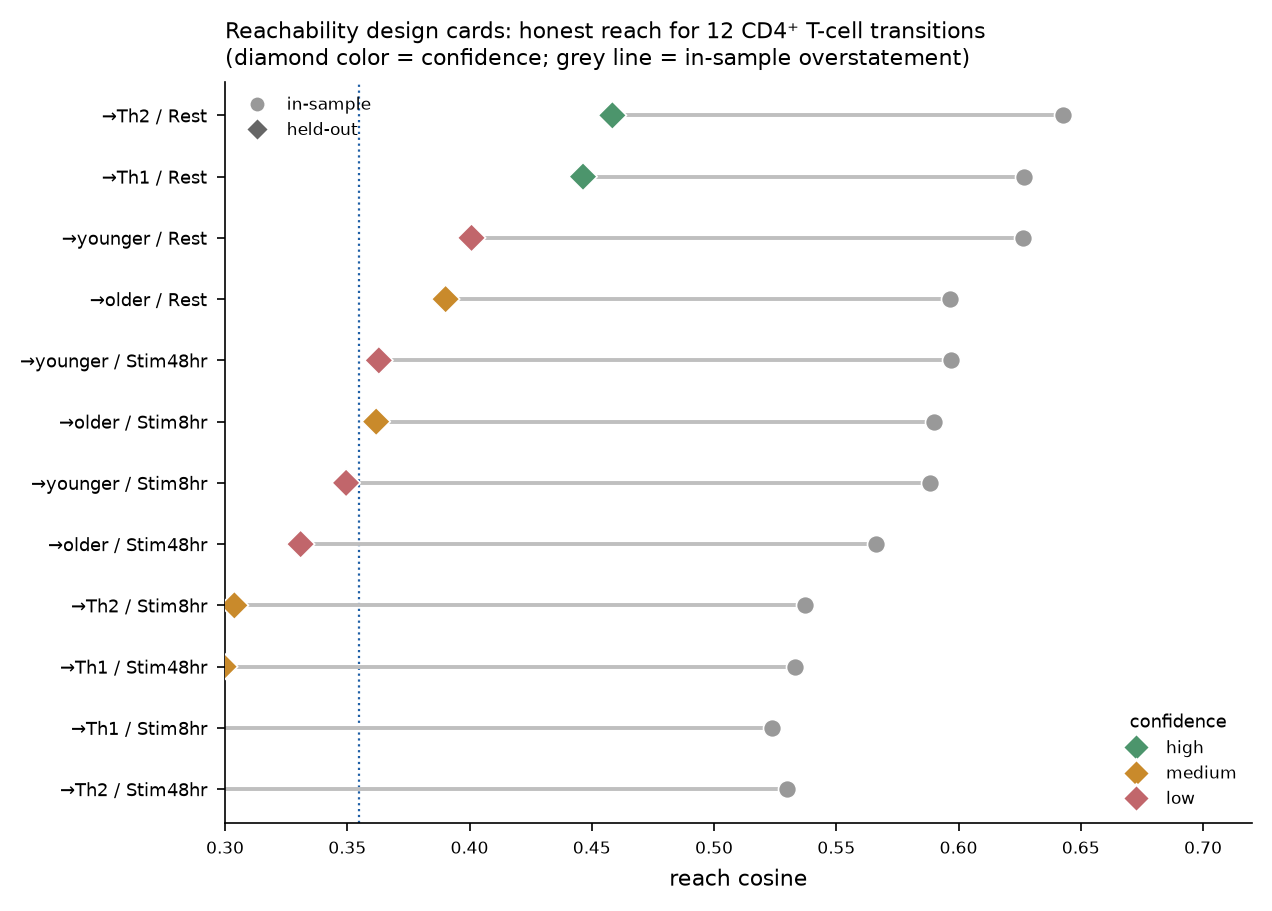

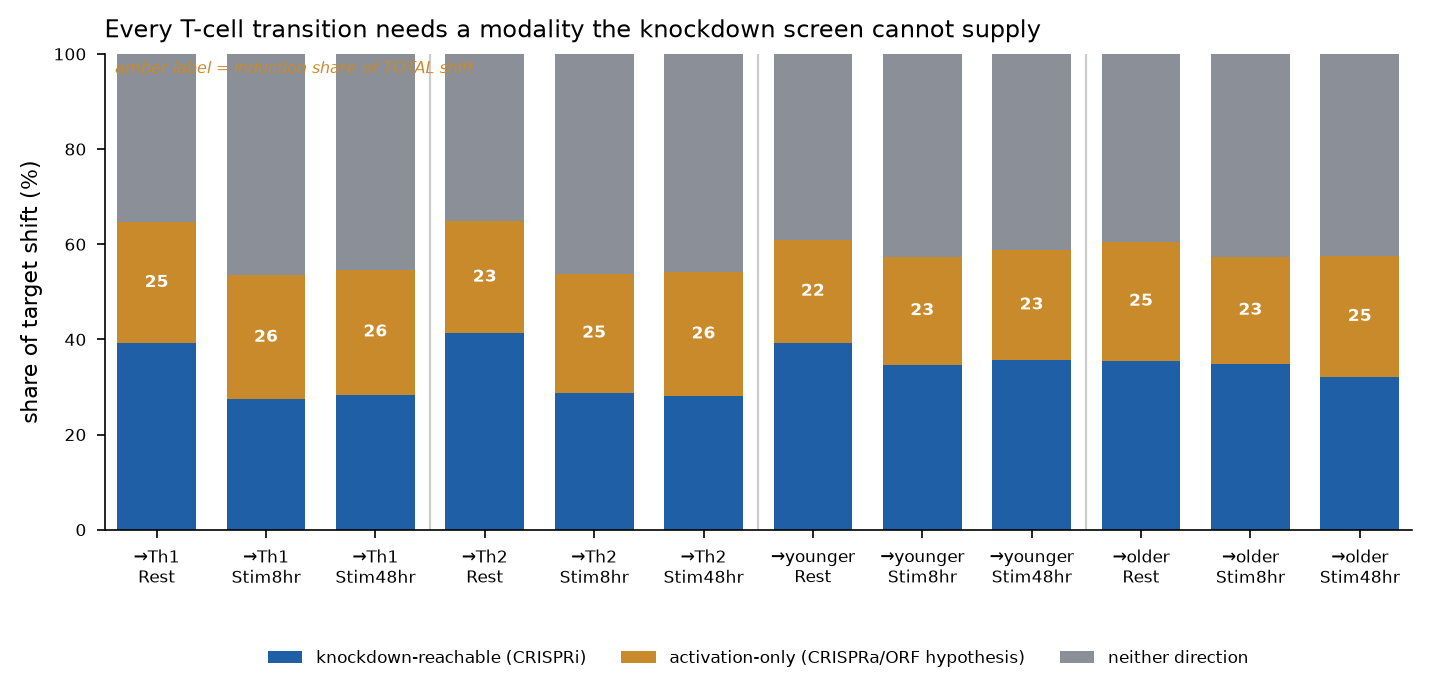

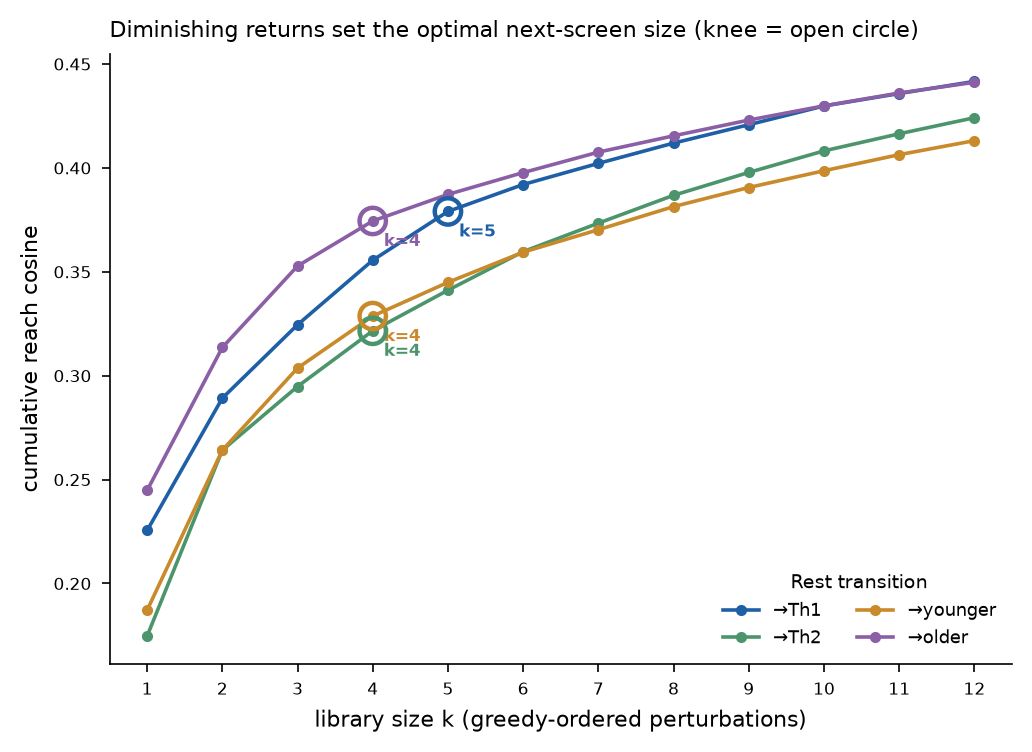

In [8]:
# The modality triage (Figure 2) — the scientific payload for a screen designer. The signed
# decomposition splits each target into a part reachable by KNOCKDOWN (what a CRISPRi screen can
# do) and a part that requires INDUCTION (activation-only, GOF). Every one of the 12 transitions
# has a substantial activation-only share: a knockdown-only screen structurally CANNOT reach it.
msum = pd.read_csv(f"{RESULTS}/design_modality_summary.csv")
moves = pd.read_csv(f"{RESULTS}/design_modality_tractability.csv")
print("=== modality triage: what fraction needs a modality the knockdown screen lacks ===")
print(f"  activation-only (GOF) share of TOTAL shift: {msum['gof_fraction'].min()*100:.0f}-{msum['gof_fraction'].max()*100:.0f}% across transitions")
print(f"  in all {len(msum)}/{len(msum)} transitions the activation SUPPORT set is larger than the knockdown one")
# tractability grounding of the recipe moves
kd = moves[moves["direction"]=="knockdown"]; ac = moves[moves["direction"]=="activation"]
# clinical-drug tier = OT_top_bucket 'clinical drug' (an approved/clinical-stage drug exists);
# this is stricter than n_drugs>0, which also counts weaker SM-ligandable / AB-surface tiers.
clin = kd[kd["OT_top_bucket"]=="clinical drug"]
n_drug = clin["gene"].nunique(); drugged = sorted(clin["gene"].unique())
print(f"\n  Open Targets grounding of {moves['gene'].nunique()} unique recipe genes:")
print(f"    knockdown targets in the 'clinical drug' tractability tier (repurposing candidates): {n_drug} genes")
print(f"      {', '.join(drugged)}")
act_notsm = int((ac["delivery_call"].str.contains("not SM-druggable")).sum())
print(f"    activation moves that are NOT small-molecule-druggable (need CRISPRa/ORF): {act_notsm}/{len(ac)} ({100*act_notsm/len(ac):.0f}%)")
print(f"\nFigure 2 (modality triage bars): {FIG}/nb04_fig2_modality_triage.png")
print(f"Figure 4 (optimal-k library curve): {FIG}/nb04_fig4_library_curve.png")
print(f"Figure 1 (design-card summary):     {FIG}/nb04_fig1_design_summary.png")

## 8 · Portable card export

`design_card_markdown()` writes a shareable Markdown card (for a slide, an issue, a lab notebook). Here we batch-export all 12.

In [9]:
# design_card_markdown(): a portable, shareable export of one card (for a slide, an issue, a lab
# notebook). Same content as render_design_card, formatted as Markdown tables.
def design_card_markdown(card: dict) -> str:
    c = card; cal = c.get("calibration", {}); mod = c.get("modality", {})
    mv = c.get("moves", []); kd = [m for m in mv if m["direction"]=="knockdown"][:8]; ac = [m for m in mv if m["direction"]=="activation"][:8]
    lib = c["library"]; kk = c["optimal_k"]
    md = [f"# Design card - {c['target']} ({c['condition']})\n",
          f"**Verdict:** {c['verdict']}  |  **Confidence:** {cal.get('confidence_label','?')}\n",
          "## Reachability\n", "| metric | value |", "|---|---|",
          f"| reach cosine (in-sample, full panel) | {c['reachable_cosine']:.3f} |"]
    if cal.get("boot_reach_cos_lo") is not None:
        md.append(f"| gene-panel bootstrap reach (85%, N=12) | mean {cal['boot_reach_cos_mean']:.3f}, 95% CI {cal['boot_reach_cos_lo']:.3f}–{cal['boot_reach_cos_hi']:.3f} |")
    if cal:
        md += [f"| reach cosine (held-out, honest) | {cal['realized_cosine']:.3f} |",
               f"| in-sample overstatement | {cal['gap']:.3f} |",
               f"| held-out significance (z) | {cal['heldout_z']:.1f} |"]
    md += [f"| knockdown-reachable (LOF) | {c['lof_fraction']*100:.1f}% |",
           f"| activation-only (GOF, CRISPRa hypothesis) | {c['gof_fraction']*100:.1f}% |",
           f"| neither direction | {c['neither_fraction']*100:.1f}% |",
           f"| optimal library size (knee) | k = {kk} |\n"]
    if mod.get("headline_modality_message"): md.append(f"> {mod['headline_modality_message']}\n")
    md += ["## Knockdown recipe (suppress - CRISPRi/degrader/inhibitor)\n", "| rank | gene | weight | delivery call |", "|---|---|---|---|"]
    md += [f"| {m['recipe_rank']} | {m['gene']} | {m['weight']:.3f} | {m['delivery_call']} |" for m in kd]
    md += ["\n## Activation recipe (induce - CRISPRa/ORF hypothesis; not testable in a knockdown screen)\n", "| rank | gene | weight | delivery call |", "|---|---|---|---|"]
    md += [f"| {m['recipe_rank']} | {m['gene']} | {m['weight']:.3f} | {m['delivery_call']} |" for m in ac]
    md += [f"\n## Optimal next-screen library (knee at k={kk})\n", "`" + " > ".join(l["gene"] for l in lib[:kk]) + "`\n", "---",
           "*in-sample reach cosine is optimistic; the held-out value is the honest estimate. "
           "The activation recipe is a sign-flip (CRISPRa) hypothesis, not a knockdown-screen result.*"]
    return "\n".join(md)

# batch-export all 12 cards to cache/cards_export/ (the standard deliverable set)
outdir = "cache/cards_export"; os.makedirs(outdir, exist_ok=True)
for tk in order:
    with open(f"{outdir}/design_card_{tk}.md", "w") as fh: fh.write(design_card_markdown(cards[tk]))
print(f"exported {len(order)} design cards (Markdown) -> {outdir}/")
print(f"example: {outdir}/design_card_toward_Th1_Rest.md ({os.path.getsize(outdir+'/design_card_toward_Th1_Rest.md')} bytes)")

exported 12 design cards (Markdown) -> cache/cards_export/
example: cache/cards_export/design_card_toward_Th1_Rest.md (2591 bytes)


## 9 · Interactive picker (live demo)

In Jupyter this is a dropdown of the 12 transitions with a live card and one-click export. It degrades to a static card when `ipywidgets` is absent, so the notebook always runs.

In [10]:
# INTERACTIVE PICKER (live demo). In Jupyter this renders a dropdown of the 12 transitions with a
# live design card and a one-click Markdown export. Requires ipywidgets; if unavailable (or run as
# a plain script) it degrades to a static print of the headline card, so the notebook always runs.
def build_picker(cards: dict, order: list):
    import ipywidgets as W
    from IPython.display import clear_output
    opts = [(f"{cards[tk]['target'].replace('toward_','->')} / {cards[tk]['condition']}"
             f"  [{cards[tk]['calibration']['confidence_label']}]", tk) for tk in order]
    dd = W.Dropdown(options=opts, description="Transition:", style={"description_width":"initial"}, layout=W.Layout(width="440px"))
    out = W.Output(); btn = W.Button(description="Export card (.md)", button_style="info", layout=W.Layout(width="200px"))
    def show(tk):
        with out: clear_output(wait=True); print(render_design_card(cards[tk]))
    dd.observe(lambda ch: show(ch["new"]) if ch["type"]=="change" and ch["name"]=="value" else None)
    def on_export(_):
        tk = dd.value; fn = f"cache/cards_export/design_card_{tk}.md"
        with open(fn,"w") as fh: fh.write(design_card_markdown(cards[tk]))
        with out: print(f"\n  exported {fn}")
    btn.on_click(on_export); show(dd.value)
    return W.VBox([W.HBox([dd, btn]), out])

try:
    import ipywidgets  # noqa
    from IPython.display import display
    picker = build_picker(cards, order)
    display(picker)                      # <- interactive in Jupyter
    print("[interactive picker ready — choose a transition above]")
except Exception as e:
    print(f"[ipywidgets unavailable ({type(e).__name__}); showing static headline card instead]")
    print(render_design_card(cards["toward_Th1_Rest"]))

  DESIGN CARD  -  toward_Th1  (Rest)
  VERDICT:  PARTIALLY REACHABLE      confidence: HIGH
  reach cosine (in-sample, full panel):  0.627
     gene-panel bootstrap (85%, N=12):  mean 0.639, 95% CI [0.633, 0.649] (robustness, not the point estimate)
  reach cosine (held-out, honest):  0.446   [in-sample overstates by 0.180]
  significance:  held-out z = 45.0

  MODALITY SPLIT (of the target norm):
     knockdown-reachable (LOF):   39.3%
     activation-only    (GOF):   25.3%   <- CRISPRa/ORF hypothesis
     neither direction        :   35.4%
     -> 39% of the addressable shift needs INDUCTION (CRISPRa/ORF); a knockdown-only screen structurally cannot reach it. 1/15 knockdown targets have an approved/clinical drug for repurposing.

  KNOCKDOWN RECIPE (suppress; screen the top 5 as the library):
      1. ICOS         w=0.254  CRISPRi or antibody blockade (surface; 4 drugs) [4 drugs]
      2. C2CD5        w=0.187  CRISPRi or antibody blockade (surface protein)
      3. ADCK2        w=0.17

## 9b · Causal-design stubs — turning the trust-layer caveats into screens

The design cards above answer *what to perturb* for a reachable target. The causal-validation
dossier (`09_causal_validation_dossier.ipynb`) surfaces two assumptions that no in-silico test can
close — they need wet-lab designs. Consistent with this notebook's "verdict → runnable experiment"
purpose, we sketch both as design stubs.

**B1 · Cytokine-spillover / SUTVA screen.** Pooled Perturb-seq lets a perturbed cell's secreted
cytokines (IFN-γ, IL-4) alter a *neighbour's* state — interference that would bias the polarization
effects the Th1/Th2 target axis is built from. The design that bounds it: run a subset of guides in
**arrayed** format (one guide per well, no cross-talk) alongside the **pooled** screen, and titrate
**MOI** in the pooled arm. Spillover shows up as an arrayed-vs-pooled effect gap that grows with MOI.

**A3 (wet-lab) · In-domain double-perturbation additivity panel.** A3's k-way bound imports its
per-pair interaction estimate from borrowed K562 doubles (Norman 2019); the CD4⁺ dictionary contains
no measured doubles of its own. The design: measure a modest panel of **double knockdowns** in the
primary CD4⁺ system, chosen to span the recipe's own generators, and fit the in-domain saturation law
directly — replacing the borrowed calibration and confirming (or relaxing) A3's pessimistic floor.
This is the additivity-assumption (II) counterpart to B1's SUTVA test, not one of the B-items.

In [98]:
# Design stubs — specifications, not runs. Sized from the headline recipe + A3 bound.
import csv as _csv, os as _os
def _find(name):
    for b in (REPO if 'REPO' in dir() else '..', '..', '.'):
        pth=_os.path.join(b,name)
        if _os.path.exists(pth): return pth
    return name
try:
    a3=list(_csv.DictReader(open(_find("a3_kway_additivity_bound.csv"))))
    ret12=float([r for r in a3 if r['recipe_size_k']=='12'][0]['additive_dir_retention'])
except Exception:
    ret12=0.29
B1 = dict(name="B1 cytokine-spillover / SUTVA",
          arms=["pooled (screen MOI)","pooled (2x MOI)","arrayed subset (24 guides)"],
          readout="arrayed-vs-pooled effect-vector cosine gap vs MOI",
          decision="gap < 0.05 across MOI => SUTVA safe for the polarization axis; else report spillover-corrected effects")
A3wl = dict(name="A3 (wet-lab) in-domain double-perturbation additivity panel",
          n_doubles=24, chosen_from="headline recipe generators (FBXO32, ICOS, RARA, ...)",
          readout="measured double vs additive-sum cosine; in-domain saturation ceiling M*",
          decision=f"replaces the borrowed Norman calibration; current k=12 directional retention ~{ret12:.2f} is a pessimistic floor to confirm/relax")
for D in (B1,A3wl):
    print(D["name"]); [print(f"    {k}: {v}") for k,v in D.items() if k!="name"]; print()

B1 cytokine-spillover / SUTVA
    arms: ['pooled (screen MOI)', 'pooled (2x MOI)', 'arrayed subset (24 guides)']
    readout: arrayed-vs-pooled effect-vector cosine gap vs MOI
    decision: gap < 0.05 across MOI => SUTVA safe for the polarization axis; else report spillover-corrected effects

A3 (wet-lab) in-domain double-perturbation additivity panel
    n_doubles: 24
    chosen_from: headline recipe generators (FBXO32, ICOS, RARA, ...)
    readout: measured double vs additive-sum cosine; in-domain saturation ceiling M*
    decision: replaces the borrowed Norman calibration; current k=12 directional retention ~0.29 is a pessimistic floor to confirm/relax



## 10 · Summary

The toolkit, and the one caveat that keeps it honest.

In [11]:
# Summary — the toolkit, and the one caveat that keeps it honest.
print("EXPERIMENTAL-DESIGN TOOLKIT — what notebook 04 delivers")
print("="*66)
print("  design_experiment(E, d)  ->  a design card with:")
print("    1. a null-calibrated reachability VERDICT (4 levels)")
print("    2. ranked KNOCKDOWN + ACTIVATION recipes (signed decomposition)")
print("    3. a per-move DELIVERY-TECHNOLOGY call grounded in Open Targets")
print("    4. an optimal next-screen LIBRARY (knee of the sparsity curve)")
print("  render_design_card / design_card_markdown  ->  shareable cards")
print("  build_picker  ->  interactive target selection + export")
print()
print("  THE CAVEAT (and why we quantify it): the in-sample reachable cosine")
print("  is optimistic. True leave-one-donor-out is impossible here (the effect")
print("  vectors are donor-collapsed), so we substitute a held-out-GENE reliability")
print(f"  diagram, gene-panel bootstrap CIs, and nulls. In-sample overstates held-out")
print(f"  reach by ~0.22 on average — the design cards report the HONEST number and")
print("  a confidence label so a screen is planned on calibrated expectations.")
print()
print("  See the experimental-design toolkit section of the Technical Dossier (docs/Technical_Dossier.md, Part 1 - Results) for the full workflow, inputs, outputs, and the calibration note.")

EXPERIMENTAL-DESIGN TOOLKIT — what notebook 04 delivers
  design_experiment(E, d)  ->  a design card with:
    1. a null-calibrated reachability VERDICT (4 levels)
    2. ranked KNOCKDOWN + ACTIVATION recipes (signed decomposition)
    3. a per-move DELIVERY-TECHNOLOGY call grounded in Open Targets
    4. an optimal next-screen LIBRARY (knee of the sparsity curve)
  render_design_card / design_card_markdown  ->  shareable cards
  build_picker  ->  interactive target selection + export

  THE CAVEAT (and why we quantify it): the in-sample reachable cosine
  is optimistic. True leave-one-donor-out is impossible here (the effect
  vectors are donor-collapsed), so we substitute a held-out-GENE reliability
  diagram, gene-panel bootstrap CIs, and nulls. In-sample overstates held-out
  reach by ~0.22 on average — the design cards report the HONEST number and
  a confidence label so a screen is planned on calibrated expectations.

  See the experimental-design toolkit section of the Technical